# Astronomy Application

In [ ]:
import sys, os
sys.path.append(os.path.join(os.path.expanduser('~'), 'Documents', 'GitHub', 'RiemannianEB', 'src'))
from utils import *

## import data, visualise

Average angular variance (in rad^2):  0.009240724037789944


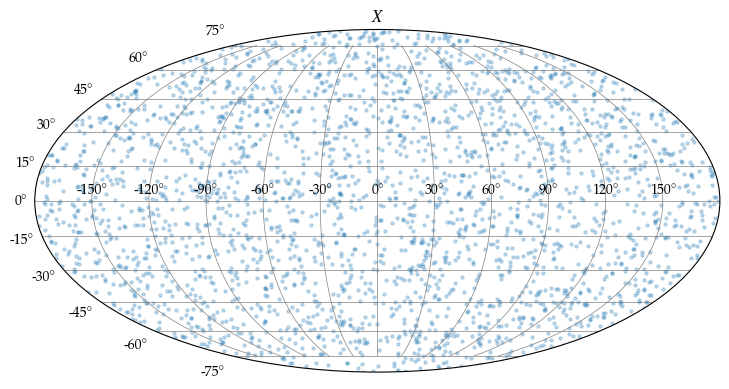

In [ ]:
df = pd.read_csv('data/BATSE_4B.txt', header=None, sep='\s+', encoding='utf-8')

# Assume column 5 = RA, column 6 = Dec (in degrees)
ra = df[5].values
dec = df[6].values
phi = np.deg2rad(ra)           # longitude
theta = np.pi/2 - np.deg2rad(dec)  # colatitude
sphere = Hypersphere(dim=2)
X_sph = np.column_stack([theta, phi])
X = sphere.spherical_to_extrinsic(X_sph)

sigma2 = np.mean(np.power(df[9].values * np.pi/180.,2))
print('Average angular variance (in rad^2): ', sigma2)

# --- plot X
fig, ax = plt.subplots(1, 1, figsize=(10, 4), subplot_kw={'projection': 'mollweide'})
S2scatter(X, ax, color='C0', alpha=0.25)  # Changed axs[0] to axs[1]
ax.set_title('$X$')
plt.tight_layout()
plt.show()

## Density estimation

In [8]:
# Grid on S^2 (theta = colatitude, phi = longitude)
res_lat = 80
res_lon = 80
grid_theta, grid_phi = np.meshgrid(
    np.linspace(0, np.pi, res_lat),        # colatitude
    np.linspace(0, 2*np.pi, res_lon)      # longitude
)
X_grid = np.stack([
    np.sin(grid_theta) * np.cos(grid_phi),
    np.sin(grid_theta) * np.sin(grid_phi),
    np.cos(grid_theta)
], axis=-1).reshape(-1,3)


M = 10
X_grid, hat_f, hat_grad_f = density_estimate('S2', X, M, X_grid)


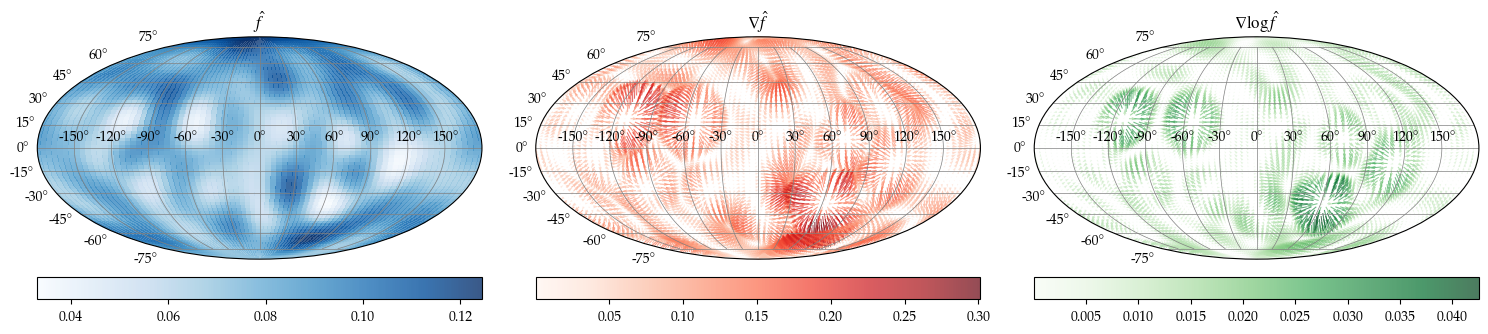

In [ ]:
fig = S2plot_density_gradient_score(X,M,sigma2,rho,skip=2, mollwide=True); 
plt.show()


## Empirical Bayes denoising

In [33]:
rho = .05
delta = denoiser('S2', X, M, rho, sigma2, X)


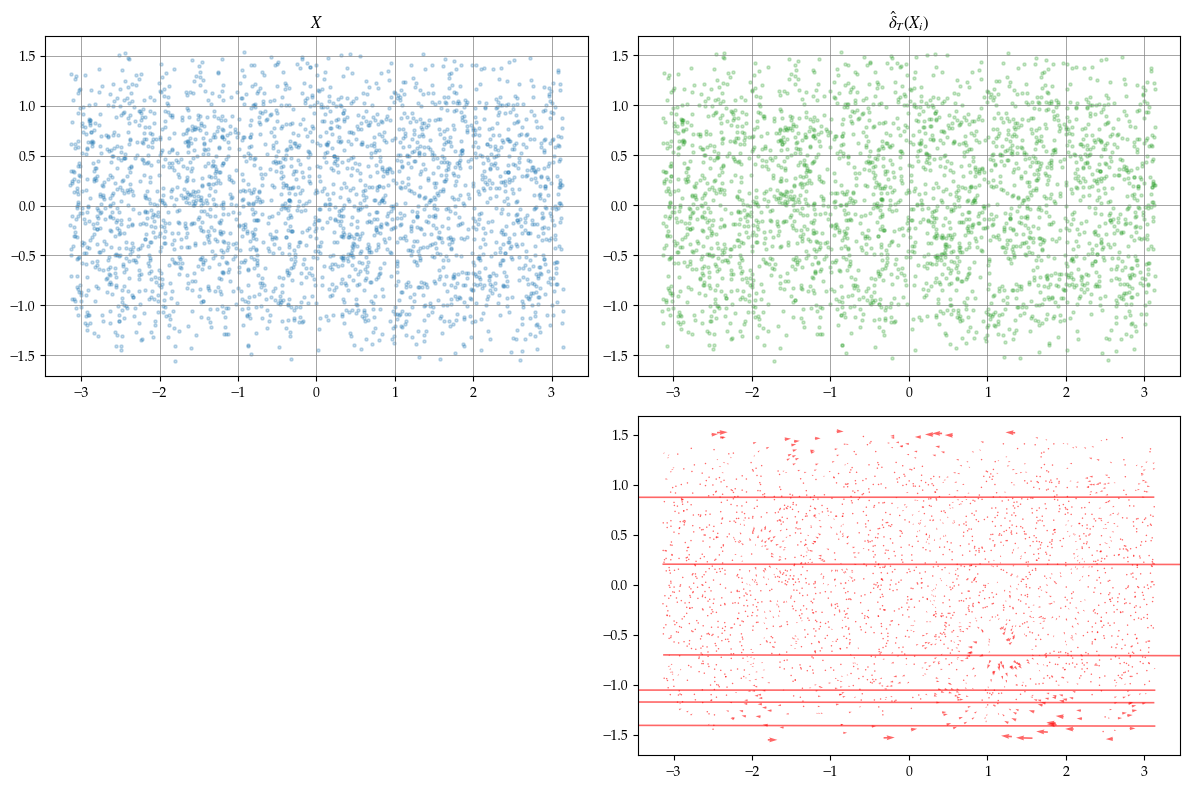

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), 
                        # subplot_kw={'projection': 'mollweide'}
                        )

# Top-left plot: X
axs[0, 0].grid(True, color='gray', lw=0.5)
axs[0, 0].set_title('$X$')
S2scatter(X, ax=axs[0, 0], color='C0', alpha=0.25)

# Top-right plot: $\hat{\delta}_T(X_i)$
axs[0, 1].grid(True, color='gray', lw=0.5)
axs[0, 1].set_title('$\\hat{\\delta}_T(X_i)$')
S2scatter(delta, ax=axs[0, 1], color='C2', alpha=0.25)

# Compute displacement vectors in spherical coordinates
# Convert to Mollweide coordinates for plotting
X_sph = sphere.extrinsic_to_spherical(X)
delta_sph = sphere.extrinsic_to_spherical(delta)
X_phi_mw = X_sph[:, 1] - np.pi
X_theta_mw = np.pi/2 - X_sph[:, 0]


delta_phi_mw = delta_sph[:, 1] - np.pi
delta_theta_mw = np.pi/2 - delta_sph[:, 0]

# Compute displacement
u = delta_phi_mw - X_phi_mw
v = delta_theta_mw - X_theta_mw

# Subsample for clearer visualization
stride = 1
axs[1,1].quiver(X_phi_mw[::stride], X_theta_mw[::stride], 
          u[::stride], v[::stride], 
          color='red', alpha=0.6, scale=5, width=0.003)

# Hide bottom-left and bottom-right axes
axs[1, 0].axis('off')

ax.grid(True, color='gray', lw=0.5)
ax.set_title('Denoiser displacement: $X_i \\rightarrow \\hat{\\delta}_T(X_i)$')
plt.tight_layout()
plt.show()

------

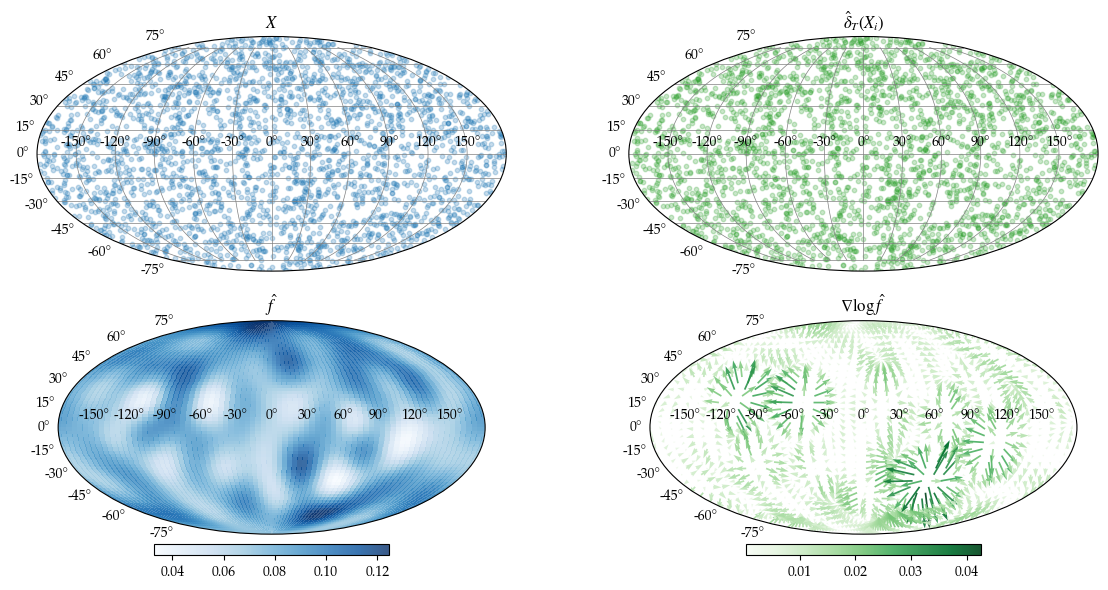

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 6), 
                        subplot_kw={'projection': 'mollweide'}
                        )
grid_phi_mw = (grid_phi - np.pi)          # longitude in [-pi, pi]
grid_theta_mw = (np.pi/2 - grid_theta)    # latitude in [-pi/2, pi/2]

# Top-left plot: X
axs[0, 0].grid(True, color='gray', lw=0.5)
axs[0, 0].set_title('$X$')
S2scatter(X, ax=axs[0, 0], color='C0', alpha=0.25, s=10)

# Top-right plot: $\hat{\delta}_T(X_i)$
axs[0, 1].set_title('$\\hat{\\delta}_T(X_i)$')
S2scatter(delta, ax=axs[0, 1], color='C2', alpha=0.25, s=10)
# ------ SECOND ROW

# Plot estimated density --------------------------------------------------
axs[1,0].set_title(r'$\hat f$')
im_f = axs[1,0].pcolormesh(grid_phi_mw, grid_theta_mw, 
                         hat_f.reshape(res_lat, res_lon),
                         alpha=0.8,shading='auto',cmap='Blues')
fig.colorbar(im_f, ax=axs[1,0], orientation='horizontal', fraction=0.05, pad=0.04)
# Plot score --------------------------------------------------
hat_score_reshaped = hat_score.reshape(res_lat, res_lon, 3)
grad_theta_score = -np.sum(hat_score_reshaped * e_theta, axis=-1) # Project score onto tangent directions
grad_phi_score = np.sum(hat_score_reshaped * e_phi, axis=-1)

axs[1,1].set_title(r'$\nabla \log \hat f$')
skip = 2
im_score = axs[1,1].quiver(grid_phi_mw[::skip, ::skip], grid_theta_mw[::skip, ::skip],
              grad_phi_score[::skip, ::skip], grad_theta_score[::skip, ::skip],
              np.sqrt(grad_theta_score**2 + grad_phi_score**2)[::skip, ::skip],
              scale=0.5, cmap='Greens', alpha=0.9, width=0.004)
fig.colorbar(im_score, ax=axs[1,1], orientation='horizontal', fraction=0.05, pad=0.04)
plt.tight_layout()
plt.show()


ax.grid(True, color='gray', lw=0.5)
ax.set_title('Denoiser displacement: $X_i \\rightarrow \\hat{\\delta}_T(X_i)$')
plt.tight_layout()
plt.show()